In [1]:
# 首格只用标准库核验，任何教学契约字节变更都先停止。
from pathlib import Path
import hashlib, json
BASE = Path.cwd()
contract = json.loads((BASE / 'data_integrity.json').read_text())
for relative, expected in contract['sha256'].items():
    if hashlib.sha256((BASE / relative).read_bytes()).hexdigest() != expected:
        raise ValueError('teaching fixture changed: ' + relative)
print('Five teaching inputs verified before numerical imports.')

Five teaching inputs verified before numerical imports.


# 第040讲 正则化与收缩估计
从同一四行的逐样本两轮更新到训练/验证选择。所有结果为有限合成教学实验。请从新内核按顺序运行；本Notebook保留实际执行输出。

## 同四行前向链
X是4×2，不额外标准化。F为平均半平方，Ridge惩罚λ‖β‖²/2只加一次。

In [2]:
import numpy as np
import experiment as e
import plots
import matplotlib.pyplot as plt
from IPython.display import display, Image
import io
def show(fig):
    buffer = io.BytesIO()
    fig.savefig(buffer, format='png', dpi=150, bbox_inches='tight')
    display(Image(data=buffer.getvalue()))
    plt.close(fig)
X, y, splits, cfg = e.load_inputs()
print('X =', X.tolist(), '\ny =', y.tolist())
beta = np.array(cfg['hand_initial'])
trace = []
for k in range(cfg['hand_steps'] + 1):
    state = e.row_ledger(X, y, beta, cfg['hand_ridge_lambda'], 0)
    state['k'] = k
    trace.append(state)
    if k < cfg['hand_steps']:
        beta = beta - cfg['hand_learning_rate'] * np.array(state['smooth_gradient'])
print('Synchronous states:', [s['beta'] for s in trace])

X = [[-1.0, -1.0], [-1.0, -0.75], [1.0, 0.75], [1.0, 1.0]] 
y = [-1.75, -2.25, 1.25, 2.75]
Synchronous states: [[0.0, 0.0], [1.0, 0.890625], [0.9853515625, 0.884521484375]]



k = 0 beta = [0.0, 0.0]
1 prediction 0.0 residual/local derivative 1.75 r2/8 0.3828125 Jacobian [-1.0, -1.0] gradient contribution [-0.4375, -0.4375]
2 prediction 0.0 residual/local derivative 2.25 r2/8 0.6328125 Jacobian [-1.0, -0.75] gradient contribution [-0.5625, -0.421875]
3 prediction 0.0 residual/local derivative -1.25 r2/8 0.1953125 Jacobian [1.0, 0.75] gradient contribution [-0.3125, -0.234375]
4 prediction 0.0 residual/local derivative -2.75 r2/8 0.9453125 Jacobian [1.0, 1.0] gradient contribution [-0.6875, -0.6875]
data gradient [-2.0, -1.78125] penalty gradient [0.0, 0.0]
F, penalty, J = 2.15625 0.0 2.15625

k = 1 beta = [1.0, 0.890625]
1 prediction -1.890625 residual/local derivative -0.140625 r2/8 0.002471923828125 Jacobian [-1.0, -1.0] gradient contribution [0.03515625, 0.03515625]
2 prediction -1.66796875 residual/local derivative 0.58203125 r2/8 0.04234504699707031 Jacobian [-1.0, -0.75] gradient contribution [-0.1455078125, -0.109130859375]
3 prediction 1.66796875 re

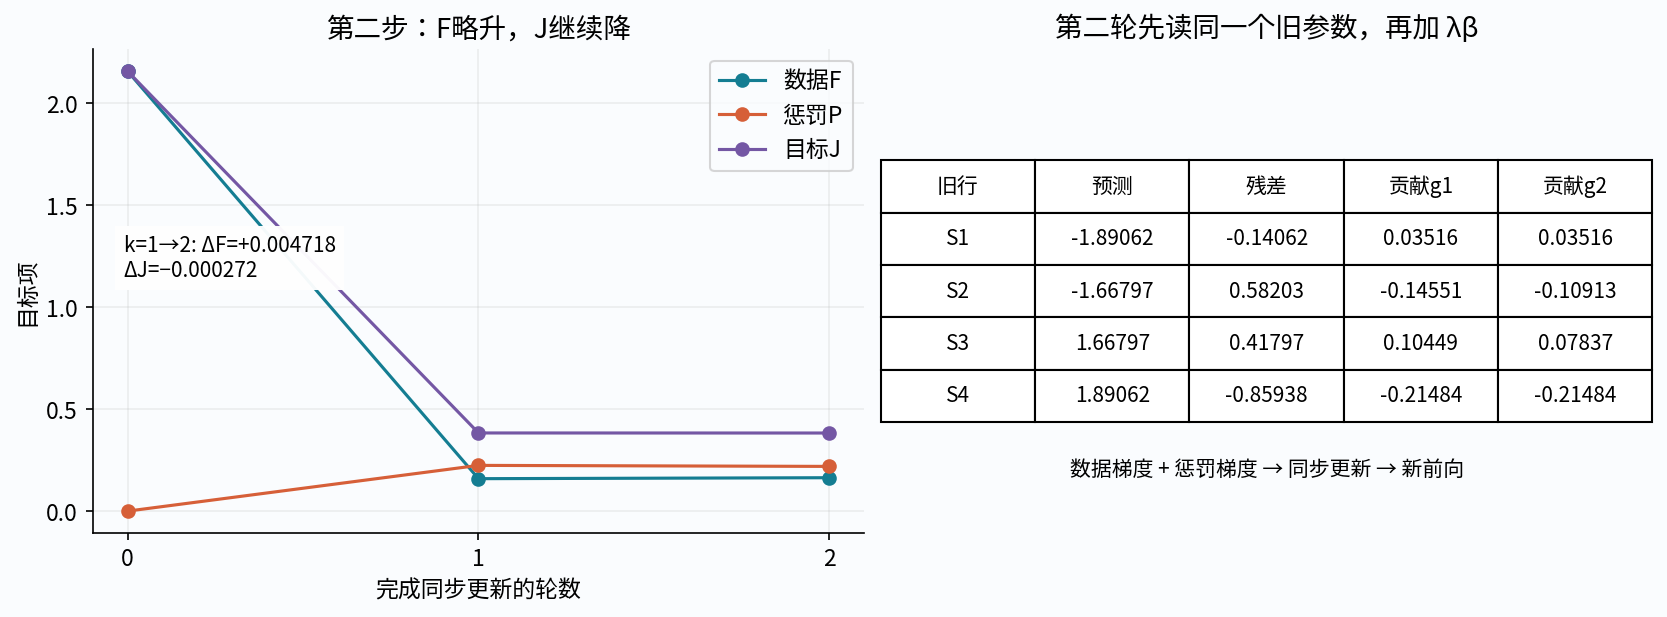

In [3]:
for state in trace:
    print('\nk =', state['k'], 'beta =', state['beta'])
    for row in state['rows']:
        print(row['id'], 'prediction', row['prediction'], 'residual/local derivative', row['residual'],
              'r2/8', row['loss_contribution'], 'Jacobian', row['jacobian'], 'gradient contribution', row['gradient_contribution'])
    print('data gradient', state['data_gradient'], 'penalty gradient', state['l2_gradient'])
    print('F, penalty, J =', state['data_loss'], state['l2_penalty'], state['objective'])
partial = {'hand_trace': trace}
fig = plots.make_figure(4, partial, X, y, splits, cfg)
show(fig)

## 三种惩罚与真实库
只在目标归一化对齐以后比较。Ridge的库alpha=nλ；另外两者alpha=λ。

In [4]:
main_fits = {}
for family, lam, rho in [('ridge', .25, 0), ('lasso', .5, 1), ('elastic', .5, .5)]:
    fit = e.fit_library(X, y, lam, family, cfg, rho)
    main_fits[family] = fit
    print(family, {k: fit[k] for k in ('beta', 'library_alpha', 'objective', 'kkt_inf', 'n_iter', 'dual_gap', 'status')})
print('Ridge independent solve:', e.ridge_solve(X, y, .25).tolist())
print('Ridge augmented least squares:', e.ridge_augmented(X, y, .25).tolist())
print('Lasso independent branches:', e.enumerate_2d(X, y, .5, 1))
print('Elastic independent branches:', e.enumerate_2d(X, y, .5, .5))
partial['main_fits'] = main_fits

ridge {'beta': [0.9626865671641793, 0.91044776119403], 'library_alpha': 1.0, 'objective': 0.38269589552238803, 'kkt_inf': 4.440892098500626e-16, 'n_iter': None, 'dual_gap': None, 'status': 'converged'}
lasso {'beta': [1.5, 0.0], 'library_alpha': 0.5, 'objective': 1.03125, 'kkt_inf': 0.0, 'n_iter': 2, 'dual_gap': 0.0, 'status': 'converged'}
elastic {'beta': [0.8880597015880654, 0.7313432835010353], 'library_alpha': 0.5, 'objective': 0.8192630597014925, 'kkt_inf': 4.848749179942047e-11, 'n_iter': 44, 'dual_gap': 4.305977796548177e-11, 'status': 'converged'}
Ridge independent solve: [0.9626865671641793, 0.9104477611940296]
Ridge augmented least squares: [0.9626865671641792, 0.9104477611940304]
Lasso independent branches: ({'signs': [1, 0], 'beta': [1.5, 0.0], 'objective': 1.03125, 'kkt_inf': 0.0}, [{'signs': [1, 0], 'beta': [1.5, 0.0], 'objective': 1.03125, 'kkt_inf': 0.0}])
Elastic independent branches: ({'signs': [1, 1], 'beta': [0.8880597014925374, 0.7313432835820894], 'objective': 0.8

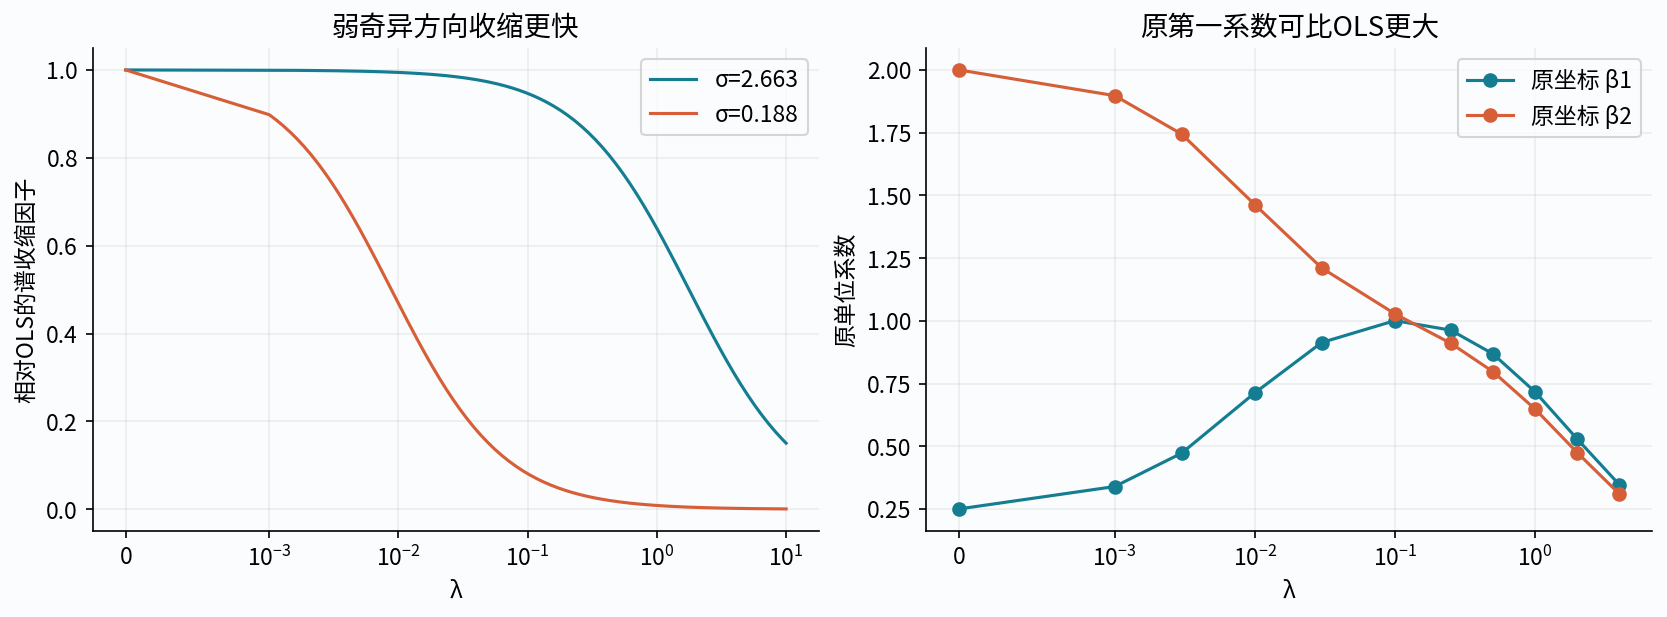

First raw coefficient: OLS = 0.25; Ridge = 0.9626865671641793


In [5]:
paths = {family: [e.fit_library(X, y, lam, family, cfg, cfg['hand_elastic_l1_ratio'])
                   for lam in cfg['path_lambdas']] for family in e.FAMILIES}
partial['paths'] = paths
fig = plots.make_figure(3, partial, X, y, splits, cfg)
show(fig)
print('First raw coefficient: OLS = 0.25; Ridge =', main_fits['ridge']['beta'][0])

Lasso data gradient: [-0.5, -0.46875] KKT components: [0.0, 0.0]


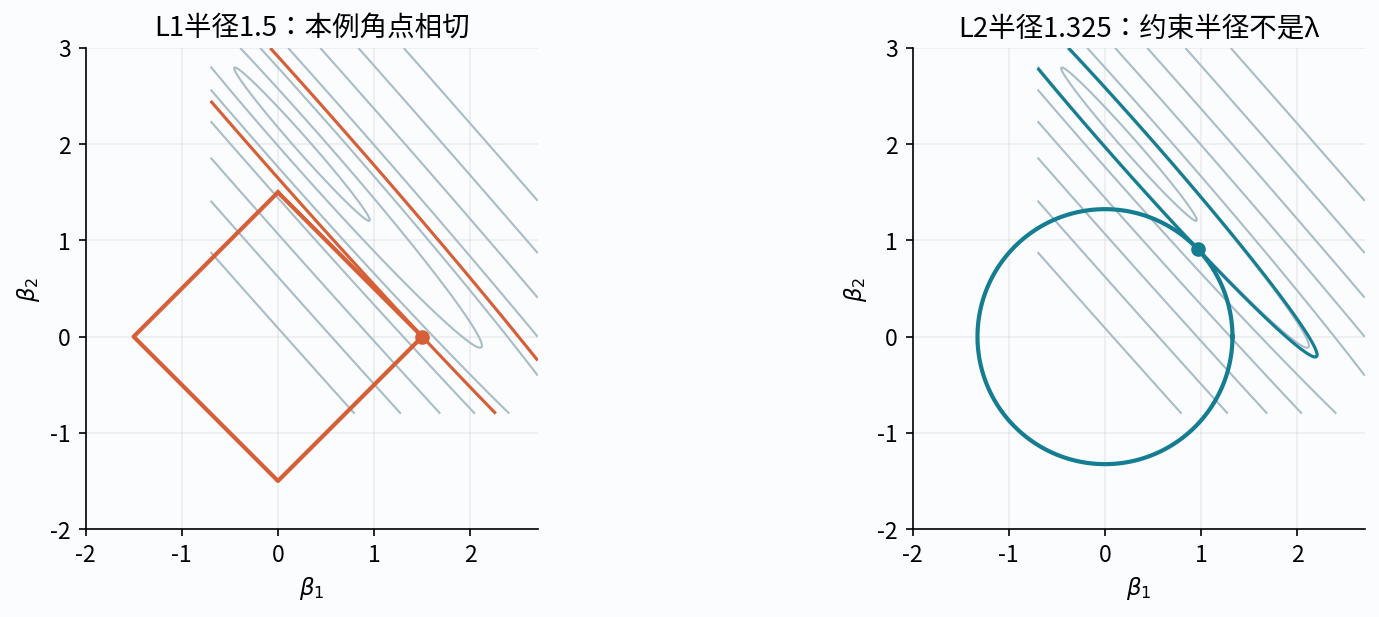

In [6]:
lasso_ledger = e.row_ledger(X, y, main_fits['lasso']['beta'], .5, 1)
print('Lasso data gradient:', lasso_ledger['data_gradient'], 'KKT components:', lasso_ledger['kkt_components'])
fig = plots.make_figure(6, partial, X, y, splits, cfg)
show(fig)

Duplicate columns: lasso [1.5, 0.0] 0.0
Duplicate columns: elastic [0.7777777779045267, 0.7777777776763788] 5.7037208289756336e-11


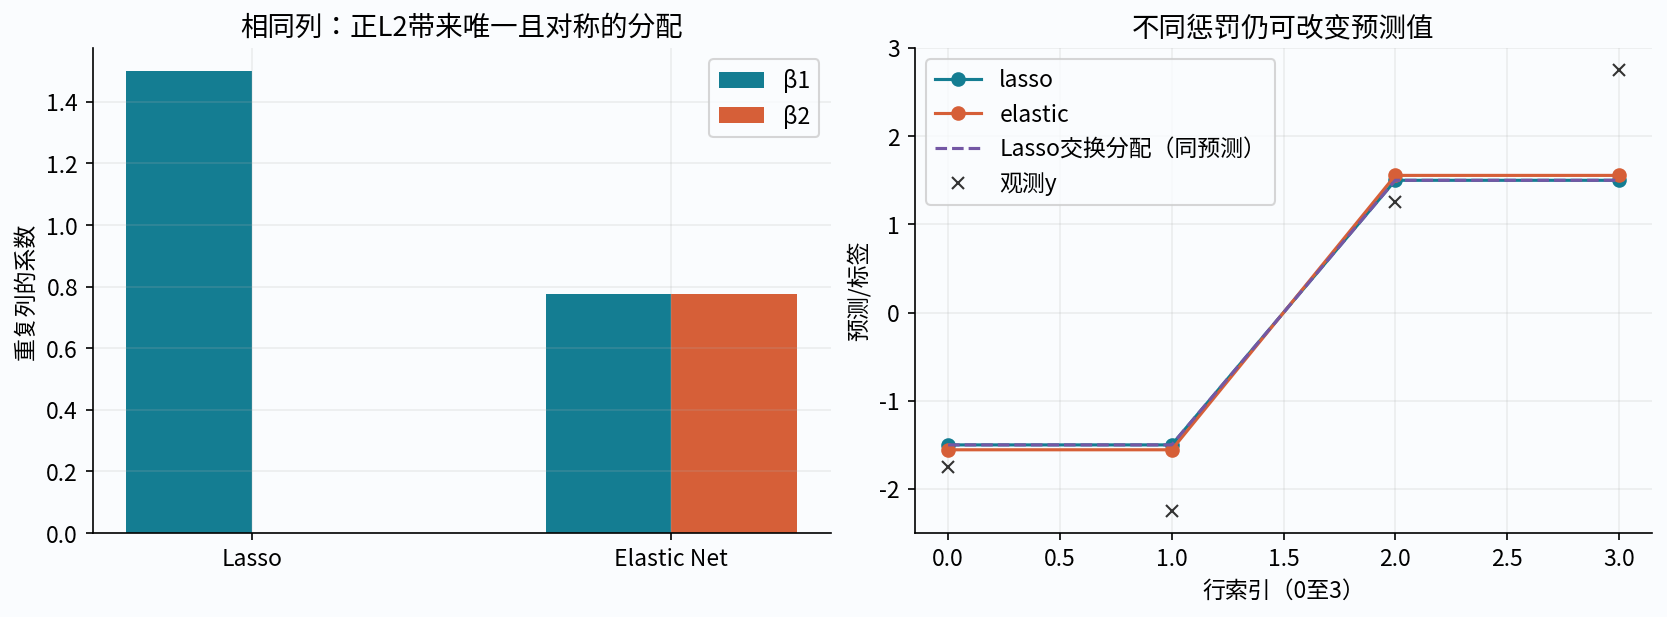

In [7]:
D = np.column_stack(([-1., -1., 1., 1.], [-1., -1., 1., 1.]))
for family in ('lasso', 'elastic'):
    fit = e.fit_library(D, y, .5, family, cfg, .5)
    print('Duplicate columns:', family, fit['beta'], fit['kkt_inf'])
fig = plots.make_figure(7, partial, X, y, splits, cfg)
show(fig)

## 固定设计Monte Carlo
这块真系数只用于机制诊断，绝不送入340行的选择函数。每个λ使用相同1000组噪声；显示真实模拟偏差。

0.0 coefficient MSE analytic/empirical: 7.125 6.688040067950667
0.01 coefficient MSE analytic/empirical: 1.5934198829782107 1.495330063345943
0.03 coefficient MSE analytic/empirical: 0.4049572199609602 0.3801856607660577
0.1 coefficient MSE analytic/empirical: 0.09033201287214399 0.0855555053131224
0.25 coefficient MSE analytic/empirical: 0.07295611494764992 0.07085406613729882
1.0 coefficient MSE analytic/empirical: 0.28173668112730565 0.2807681178145291
4.0 coefficient MSE analytic/empirical: 0.9676943854659584 0.9673731162221519


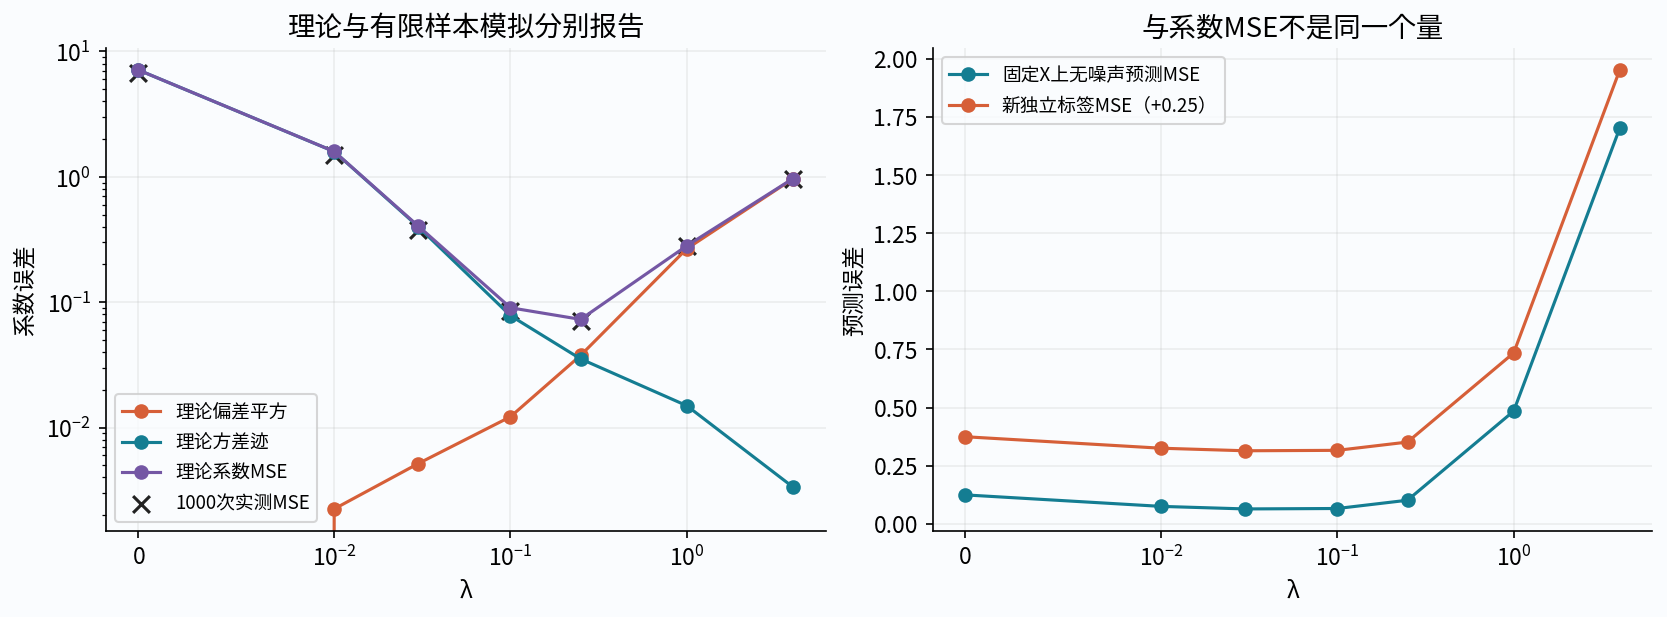

In [8]:
mc = e.monte_carlo(X, cfg)
partial['monte_carlo'] = mc
for record in mc['records']:
    print(record['lambda'], 'coefficient MSE analytic/empirical:', record['analytic_coefficient_mse'], record['empirical_coefficient_mse'])
fig = plots.make_figure(5, partial, X, y, splits, cfg)
show(fig)

## 训练/验证锁定选择
下面函数不接受测试数据或真系数。只用训练统计量变换；先比较40个预声明候选。

Candidate count: 40
Chosen: {'family': 'lasso', 'lambda': 0.03, 'l1_ratio': 1.0, 'validation_mse': 0.8075416194067659, 'train_mse': 0.7513076741771976, 'stored_exact_zeros': 5, 'kkt_inf': 1.505802843526638e-10}
Frozen choice-fit SHA256: 1c500b794b850b97a352e949156f219c799f1d63e09703c57c3543a455fa28f7


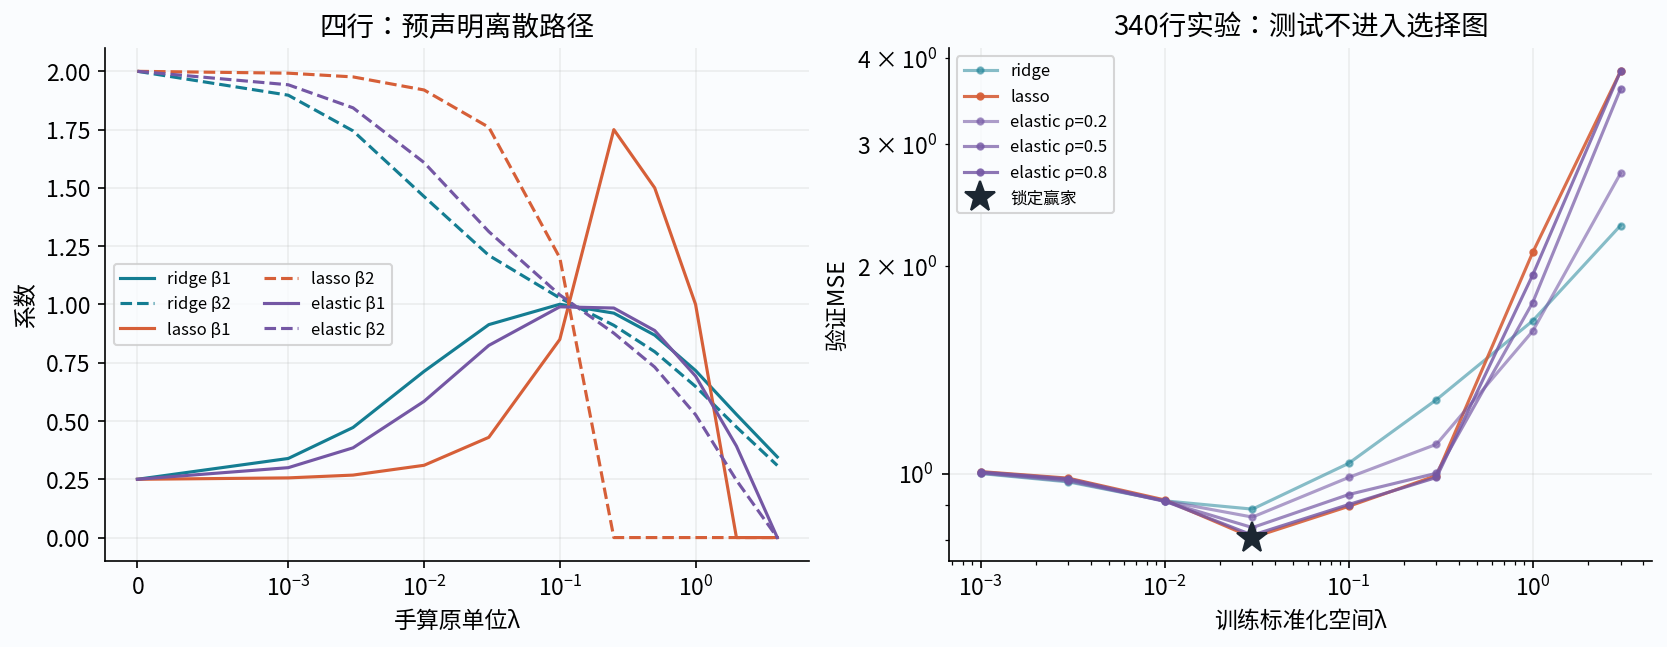

In [9]:
selected = e.select_candidate(splits['train']['X'], splits['train']['y'],
                              splits['validation']['X'], splits['validation']['y'], cfg)
partial['selection'] = selected
chosen = selected['chosen']
print('Candidate count:', len(selected['candidates']))
print('Chosen:', {k: chosen[k] for k in ('family', 'lambda', 'l1_ratio', 'validation_mse', 'train_mse', 'stored_exact_zeros', 'kkt_inf')})
print('Frozen choice-fit SHA256:', selected['choice_fit_sha256'])
fig = plots.make_figure(9, partial, X, y, splits, cfg)
show(fig)

Training mean, first five: [2.995519639796275, -3.3395106238016155, 0.4825138950581172, -0.15734769478995062, -0.020234238098636396]
Raw beta, first five: [2.1354268656633564, -0.10210358543676358, 4.877701846811681, 0.0, 1.4127490349813794]
Standardized gamma, first five: [1.972275823580473, -0.8868201911093849, 0.4494727960227432, 0.0, 1.5040733298761395]


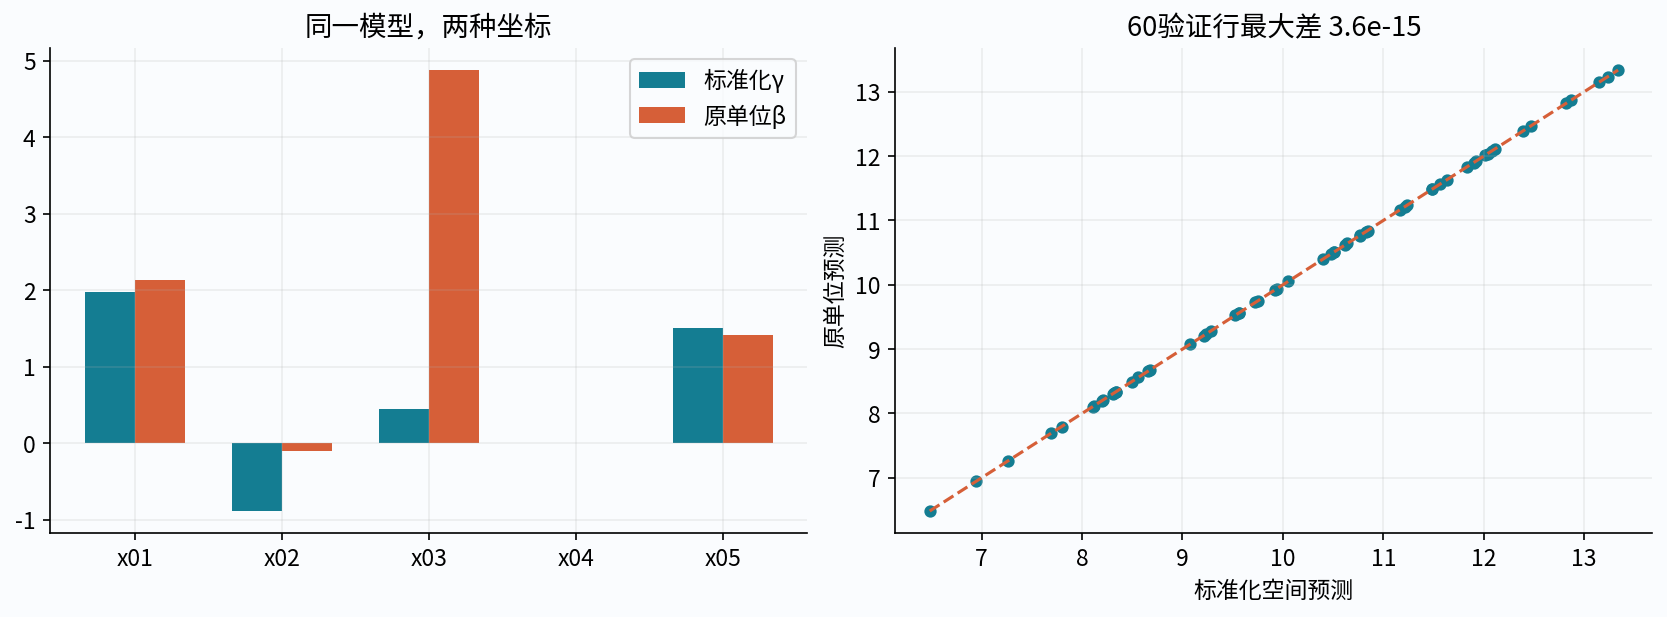

In [10]:
print('Training mean, first five:', selected['preprocessing']['mean'][:5])
print('Raw beta, first five:', chosen['coefficient_raw'][:5])
print('Standardized gamma, first five:', chosen['coefficient_standardized'][:5])
fig = plots.make_figure(8, partial, X, y, splits, cfg)
show(fig)

## 锁定之后才查看测试
只报告已经选定的赢家与事先声明的OLS基线；不按测试曲线改网格或重新选择。

In [11]:
frozen = e.canonical_bytes(selected)
final = e.final_evaluate(chosen, splits['test']['X'], splits['test']['y'])
baseline = e.final_evaluate(selected['baseline_ols'], splits['test']['X'], splits['test']['y'])
print('Final chosen test MSE:', final['mse'])
print('Predeclared OLS test MSE:', baseline['mse'])
mutated = e.final_evaluate(chosen, splits['test']['X'], splits['test']['y'] + 100)
if e.canonical_bytes(selected) != frozen:
    raise RuntimeError('test evaluation changed selected model')
if mutated['mse'] == final['mse']:
    raise RuntimeError('test-label mutation had no effect on score')
print('Test-label mutation changes score, not choice:', mutated['mse'])

Final chosen test MSE: 0.9373574730192129
Predeclared OLS test MSE: 1.075616108681604
Test-label mutation changes score, not choice: 10017.813787528972


In [12]:
for family, lam, rho in [('ridge', .25, 0), ('lasso', .5, 1), ('elastic', .5, .5)]:
    a = e.fit_library(X, y, lam, family, cfg, rho)
    b = e.fit_library(np.tile(X, (2, 1)), np.tile(y, 2), lam, family, cfg, rho)
    print(family, 'alpha before/after:', a['library_alpha'], b['library_alpha'],
          'maximum coefficient change:', float(np.max(np.abs(np.array(a['beta']) - b['beta']))))

ridge alpha before/after: 1.0 2.0 maximum coefficient change: 7.771561172376096e-16
lasso alpha before/after: 0.5 0.5 maximum coefficient change: 0.0
elastic alpha before/after: 0.5 0.5 maximum coefficient change: 2.220446049250313e-16


## 真正运行失败，再检查失败的含义
not_converged、solver_error、selection_failed与输入拒绝不是同一种情况；审计分别核验。

In [13]:
short = dict(cfg, solver_max_iter=1)
failed = e.fit_library(X, y, .001, 'elastic', short, .5)
print('One-iteration run:', failed['status'], failed['n_iter'], failed['warnings'])
bad = X.tolist(); bad[-1][-1] = True
try:
    e.ridge_solve(bad, y, .25)
except ValueError as error:
    print('Bad final scalar rejected:', str(error))
else:
    raise RuntimeError('bool accepted')

One-iteration run: not_converged 1 [{'category': 'ConvergenceWarning', 'message': 'Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.168e-01, tolerance: 1.725e-09'}]
Bad final scalar rejected: X requires a real numeric scalar, not bool/string/complex


In [14]:
import audit
checks = audit.run_audit()
print('Independent author checks:', checks['checks'])
print(checks['groups'])
print('Finite MC mean discrepancy:', checks['monte_carlo'])

Independent author checks: 768
{'fraction_rows': 60, 'fraction_states': 7, 'exact_solutions': 2, 'random_fraction': 240, 'decimal_condition': 15, 'smooth_finite_difference': 80, 'spectral_reference': 80, 'library_reference': 6, 'sample_duplication': 6, 'endpoints': 5, 'all_path_branches': 66, 'rank_deficient': 6, 'library_failure': 2, 'regeneration': 7, 'test_isolation': 2, 'train_scaler': 43, 'coordinate_backtransform': 40, 'constant_column': 2, 'selection_failures': 1, 'tie_rule': 1, 'precompute_guards': 42, 'json_guards': 4, 'csv_guards': 4, 'file_guards': 13, 'fixture_guards': 6, 'MC_independent_fit': 7, 'MC_identity': 21}
Finite MC mean discrepancy: {'max_absolute_mean_deviation': 0.012722598703599042, 'note': 'finite Monte Carlo discrepancy is reported, not required to be exactly zero'}


## 保存可与独立脚本逐字节比较的完整核心
所有行、所有候选、测试结果、全部Monte Carlo噪声与系数都在JSON。Notebook图是本次实际计算，并非仅显示旧图片。

In [15]:
report = e.main_report(X, y, splits, cfg)
if report['hand_trace'] != trace or report['selection'] != selected or report['monte_carlo'] != mc:
    raise RuntimeError('full report disagrees with staged notebook computation')
e.safe_write(BASE / 'outputs/notebook_result.json', report)
print('Whole core SHA256:', hashlib.sha256(e.canonical_bytes(report)).hexdigest())
print('Complete report saved to outputs/notebook_result.json')

Whole core SHA256: bb33e78f8da173e89395c97f6f38acdc57648d3965a9728e541e35dca7c13b2f
Complete report saved to outputs/notebook_result.json
